In [1]:
## Importing Libraries

from ultralytics import YOLO

import os
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Setting Paths

ROOT_DIR = Path.cwd().parent

DATASET_DIR = ROOT_DIR / "datasets" / "processed_dataset"

TRAIN_IMAGES = DATASET_DIR / "images" / "train"
VAL_IMAGES = DATASET_DIR / "images" / "val"
TEST_IMAGES = DATASET_DIR / "images" / "test"

TRAIN_LABELS = DATASET_DIR / "labels" / "train"
VAL_LABELS = DATASET_DIR / "labels" / "val"
TEST_LABELS = DATASET_DIR / "labels" / "test"

MODELS_DIR = ROOT_DIR / "models" / "YOLO"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Paths Ready.")

Paths Ready.


In [3]:
## Dataset Summary

print("Train Images :", len(list(TRAIN_IMAGES.glob("*"))))
print("Val Images   :", len(list(VAL_IMAGES.glob("*"))))
print("Test Images  :", len(list(TEST_IMAGES.glob("*"))))

print()

print("Train Labels :", len(list(TRAIN_LABELS.glob("*.txt"))))
print("Val Labels   :", len(list(VAL_LABELS.glob("*.txt"))))
print("Test Labels  :", len(list(TEST_LABELS.glob("*.txt"))))

Train Images : 3948
Val Images   : 846
Test Images  : 847

Train Labels : 3948
Val Labels   : 846
Test Labels  : 847


In [4]:
## Verifying Labels

classes_found = set()

for label_file in TRAIN_LABELS.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f.readlines():
            class_id = int(line.split()[0])
            classes_found.add(class_id)

print("Classes Found:")
print(sorted(classes_found))

Classes Found:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


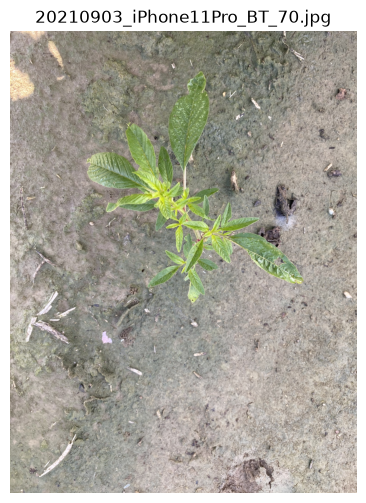

In [5]:
## Visulizing Random Images

image_path = random.choice(list(TRAIN_IMAGES.glob("*")))

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.title(image_path.name)
plt.axis("off")
plt.show()

In [6]:
## Creating Class Names

CLASS_NAMES = ["class_0", "class_1", "class_2", "class_3", "class_4", "class_5", "class_6", "class_7", "class_8", "class_9", "class_10", "class_11"]

print("Total Classes :", len(CLASS_NAMES))

Total Classes : 12


In [7]:
## Checking File Existence

print(DATASET_DIR / "data.yaml")
print((DATASET_DIR / "data.yaml").exists())

c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset\data.yaml
True


In [8]:
## Reading Existing data.yaml file

yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

print(config)

{'path': 'c:\\Users\\Akshat\\Desktop\\Over_Here\\Data Vidwan Internship\\AgroWeedGuard (Capstone Project)\\datasets\\processed_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 12, 'names': ['weed: mollugo verticillata', 'weed: amaranthus palmeri', 'weed: eclipta', 'weed: portulaca oleracea', 'weed: amaranthus tuberculatus', 'weed: euphorbia maculata', 'weed: ipomoea indica', 'weed: eleusine indica', 'weed: sida rhombifolia', 'weed: senna obtusifolia', 'weed: physalis angulata', 'weed: ambrosia artemisiifolia']}


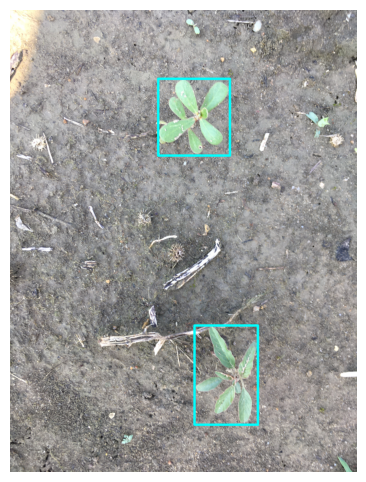

In [9]:
## Visualizing Bounding Boxes

image_path = random.choice(list(TRAIN_IMAGES.glob("*")))
label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

with open(label_path, "r") as f:
    for line in f.readlines():
        cls, x, y, bw, bh = map(float, line.split())

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)

        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 20)

plt.figure(figsize=(8,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [10]:
## Loading YOLO Model

model = YOLO("yolov8n.pt")
model.save(str(MODELS_DIR / "yolov8n_initial.pt"))

print("YOLO Model Loaded.")

YOLO Model Loaded.


In [11]:
## Model Loading & Dataset Verification 

MODEL_PATH = MODELS_DIR / "yolov8n.pt"
model = YOLO(str(MODEL_PATH))

model.train(data=str(yaml_path), epochs=1, imgsz=640, batch=8, project=str(MODELS_DIR), name="dataset_check")

New https://pypi.org/project/ultralytics/8.4.117 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.103  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001D8EFD768A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.04504

In [15]:
## Training Configuration

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 32

print(f"Epochs     : {EPOCHS}")
print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")

Epochs     : 50
Image Size : 640
Batch Size : 32


In [16]:
## Loading YOLO Model

model = YOLO(MODELS_DIR / "dataset_check" / "weights" / "last.pt")

print("Model Loaded Successfully.")

Model Loaded Successfully.


In [17]:
## Training Model

results = model.train(data=str(yaml_path), epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE, project=str(MODELS_DIR), name="yolov8n_weed_detector", device=0, patience=10, save=True)

New https://pypi.org/project/ultralytics/8.4.117 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.103  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None,

In [ ]:
## Loading Best Model

BEST_MODEL = MODELS_DIR / "yolov8n_weed_detector" / "weights" / "best.pt"
model = YOLO(str(BEST_MODEL))

print("Best Model Loaded.")

Best Model Loaded.


In [19]:
## Checking Evaluation Metrics

metrics = model.val()

print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

Ultralytics 8.4.103  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1216.3198.3 MB/s, size: 5799.3 KB)
val: Scanning C:\Users\Akshat\Desktop\Over_Here\Data Vidwan Internship\AgroWeedGuard (Capstone Project)\datasets\processed_dataset\labels\val.cache... 846 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 846/846  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 2.2it/s 23.6s0.4ss
                   all        846       1393      0.943       0.89      0.952       0.89
weed: mollugo verticillata         91        135      0.897      0.708      0.874      0.767
weed: amaranthus palmeri         46         56      0.942      0.863       0.92      0.865
         weed: eclipta         81        128      0.975      0.938      0.984      0.959
weed: portula